In [1]:
# =============================================================================
# SUPERSTORE SALES ANALYSIS
# A Professional Data Analysis Portfolio Project
# =============================================================================
# Dataset: Superstore Sales Dataset (Kaggle)
# Author: [Your Name]
# Date: 2025
# Description: End-to-end sales analysis to uncover business insights
#              from a retail superstore's transaction data.
# =============================================================================

# --- CELL 1: Import Libraries ---
# We start by importing all the tools we need for this analysis

import pandas as pd                    # For data manipulation and analysis
import matplotlib.pyplot as plt        # For creating visualizations
import matplotlib.ticker as mticker    # For formatting chart axes
import seaborn as sns                  # For beautiful statistical charts
import warnings                        # To suppress unnecessary warnings

# Suppress warnings to keep the notebook clean
warnings.filterwarnings('ignore')

# Set a consistent visual style for all charts
# "whitegrid" gives us a clean look with subtle grid lines
sns.set_theme(style="whitegrid", palette="muted")

# Set default figure size so charts aren't too small
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")

✅ Libraries imported successfully!
Pandas version: 3.0.2


In [2]:
# =============================================================================
# SECTION 1: DATA LOADING AND FIRST EXPLORATION
# =============================================================================
# Goal: Load the dataset and understand its basic structure before
#       doing any analysis. Think of this as "opening the box" to see
#       what we're working with.
# =============================================================================

In [3]:
# --- CELL 2: Load the Dataset ---

# Load the CSV file into a pandas DataFrame
# If you downloaded from Kaggle, the file is typically called 'Sample - Superstore.csv'
# Encoding 'latin1' handles special characters that may appear in the file

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

# Quick confirmation that loading worked
print(f"✅ Dataset loaded successfully!")
print(f"📊 Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

✅ Dataset loaded successfully!
📊 Dataset shape: 9,994 rows × 21 columns


In [4]:
# --- CELL 3: First Look at the Data ---

# Preview the first 5 rows to understand what the data looks like
print("=" * 60)
print("FIRST 5 ROWS OF THE DATASET")
print("=" * 60)
df.head()

FIRST 5 ROWS OF THE DATASET


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
# --- CELL 4: Column Names and Data Types ---

# Understanding what each column is and its data type
# This helps us know what needs to be fixed before analysis

print("=" * 60)
print("COLUMN NAMES AND DATA TYPES")
print("=" * 60)
print(df.dtypes)
print()
print(f"Total columns: {len(df.columns)}")

COLUMN NAMES AND DATA TYPES
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Total columns: 21


In [6]:
# --- CELL 5: Basic Dataset Statistics ---

# Get a statistical summary of all numeric columns
# This gives us a "bird's eye view" of the numbers

print("=" * 60)
print("STATISTICAL SUMMARY (Numeric Columns)")
print("=" * 60)
df.describe().round(2)

STATISTICAL SUMMARY (Numeric Columns)


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,4997.50,55190.38,229.86,3.79,0.16,28.66
std,2885.16,32063.69,623.25,2.23,0.21,234.26
min,1.00,1040.00,0.44,1.00,0.00,-6599.98
25%,2499.25,23223.00,17.28,2.00,0.00,1.73
50%,4997.50,56430.50,54.49,3.00,0.20,8.67
75%,7495.75,90008.00,209.94,5.00,0.20,29.36
max,9994.00,99301.00,22638.48,14.00,0.80,8399.98


In [7]:
# --- CELL 6: Check for Missing Values ---

# Missing values are gaps in our data — like empty cells in a spreadsheet
# We need to find them before they mess up our analysis

print("=" * 60)
print("MISSING VALUES REPORT")
print("=" * 60)

# Calculate missing values and their percentage
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)

# Combine into a readable table
missing_report = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent
})

# Only show columns that actually have missing values
missing_report = missing_report[missing_report['Missing Count'] > 0]

if missing_report.empty:
    print("✅ Great news! No missing values found in this dataset.")
else:
    print(missing_report)
    print(f"\nTotal columns with missing values: {len(missing_report)}")

MISSING VALUES REPORT
✅ Great news! No missing values found in this dataset.


In [8]:
# --- CELL 7: Check for Duplicate Rows ---

# Duplicate rows can inflate our totals and skew results
# We check for them before any calculations

duplicate_count = df.duplicated().sum()

print("=" * 60)
print("DUPLICATE ROWS CHECK")
print("=" * 60)
if duplicate_count == 0:
    print("✅ No duplicate rows found.")
else:
    print(f"⚠️  Found {duplicate_count:,} duplicate rows — will be removed in cleaning step.")

DUPLICATE ROWS CHECK
✅ No duplicate rows found.


In [9]:
# --- CELL 8: Unique Values in Key Categorical Columns ---

# Understanding how many unique categories exist in important columns
# This tells us how diverse our data is

print("=" * 60)
print("UNIQUE VALUES IN KEY COLUMNS")
print("=" * 60)

key_columns = ['Category', 'Sub-Category', 'Region', 'Segment', 'Ship Mode']

for col in key_columns:
    if col in df.columns:
        unique_vals = df[col].unique()
        print(f"\n📌 {col} ({len(unique_vals)} unique values):")
        print(f"   {list(unique_vals)}")

UNIQUE VALUES IN KEY COLUMNS

📌 Category (3 unique values):
   ['Furniture', 'Office Supplies', 'Technology']

📌 Sub-Category (17 unique values):
   ['Bookcases', 'Chairs', 'Labels', 'Tables', 'Storage', 'Furnishings', 'Art', 'Phones', 'Binders', 'Appliances', 'Paper', 'Accessories', 'Envelopes', 'Fasteners', 'Supplies', 'Machines', 'Copiers']

📌 Region (4 unique values):
   ['South', 'West', 'Central', 'East']

📌 Segment (3 unique values):
   ['Consumer', 'Corporate', 'Home Office']

📌 Ship Mode (4 unique values):
   ['Second Class', 'Standard Class', 'First Class', 'Same Day']


In [10]:
# =============================================================================
# SECTION 2: DATA CLEANING
# =============================================================================
# Goal: Fix any issues we found during exploration so our analysis
#       is accurate. Clean data = reliable conclusions.
# =============================================================================

In [11]:
# --- CELL 9: Fix Date Columns ---

# The date columns were loaded as text (strings) — we need to convert
# them to actual date format so we can do time-based analysis

print("Before conversion:")
print(f"  Order Date type: {df['Order Date'].dtype}")
print(f"  Ship Date type:  {df['Ship Date'].dtype}")

# Convert to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=False)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=False)

print("\nAfter conversion:")
print(f"  Order Date type: {df['Order Date'].dtype}")
print(f"  Ship Date type:  {df['Ship Date'].dtype}")
print("\n✅ Date columns converted successfully!")

Before conversion:
  Order Date type: object
  Ship Date type:  object

After conversion:
  Order Date type: datetime64[ns]
  Ship Date type:  datetime64[ns]

✅ Date columns converted successfully!


In [12]:
# --- CELL 10: Extract Useful Date Features ---

# Now that dates are in proper format, we can extract useful pieces
# like year, month, and quarter — these will be needed for trend analysis

df['Order Year']    = df['Order Date'].dt.year
df['Order Month']   = df['Order Date'].dt.month
df['Order Quarter'] = df['Order Date'].dt.quarter

# Create a readable Month-Year label for charts (e.g., "2023-Jan")
df['Month Year'] = df['Order Date'].dt.to_period('M').astype(str)

# Calculate how many days it took to ship each order
df['Days to Ship'] = (df['Ship Date'] - df['Order Date']).dt.days

print("✅ New date-based columns created:")
print("   - Order Year, Order Month, Order Quarter")
print("   - Month Year (for time series charts)")
print("   - Days to Ship (shipping speed)")
print(f"\nSample 'Days to Ship' values: {df['Days to Ship'].describe().round(1).to_dict()}")

✅ New date-based columns created:
   - Order Year, Order Month, Order Quarter
   - Month Year (for time series charts)
   - Days to Ship (shipping speed)

Sample 'Days to Ship' values: {'count': 9994.0, 'mean': 4.0, 'std': 1.7, 'min': 0.0, '25%': 3.0, '50%': 4.0, '75%': 5.0, 'max': 7.0}


In [13]:
# --- CELL 11: Remove Duplicates ---

# Remove any duplicate rows we found during exploration
rows_before = len(df)
df = df.drop_duplicates()
rows_after = len(df)

print(f"Rows before cleaning: {rows_before:,}")
print(f"Rows after removing duplicates: {rows_after:,}")
print(f"Rows removed: {rows_before - rows_after:,}")
print("\n✅ Duplicate removal complete!")

Rows before cleaning: 9,994
Rows after removing duplicates: 9,994
Rows removed: 0

✅ Duplicate removal complete!


In [14]:
# --- CELL 12: Verify Numeric Columns ---

# Make sure Sales, Profit, and Quantity have no negative or nonsensical values
# (negative sales could indicate returns, which we should be aware of)

print("=" * 60)
print("NUMERIC COLUMN VALIDATION")
print("=" * 60)

numeric_cols = ['Sales', 'Profit', 'Quantity', 'Discount']

for col in numeric_cols:
    negatives = (df[col] < 0).sum()
    print(f"  {col}: min={df[col].min():.2f}, max={df[col].max():.2f}, "
          f"negatives={negatives:,}")

print("\n📝 Note: Negative profits are expected (losses on some orders)")
print("✅ Numeric validation complete!")

NUMERIC COLUMN VALIDATION
  Sales: min=0.44, max=22638.48, negatives=0
  Profit: min=-6599.98, max=8399.98, negatives=1,871
  Quantity: min=1.00, max=14.00, negatives=0
  Discount: min=0.00, max=0.80, negatives=0

📝 Note: Negative profits are expected (losses on some orders)
✅ Numeric validation complete!


In [15]:
# --- CELL 13: Final Cleaned Dataset Summary ---

print("=" * 60)
print("CLEANED DATASET SUMMARY")
print("=" * 60)
print(f"  Rows:    {df.shape[0]:,}")
print(f"  Columns: {df.shape[1]}")
print(f"  Date range: {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")
print(f"  Years covered: {sorted(df['Order Year'].unique())}")
print(f"\n✅ Data is clean and ready for analysis!")

CLEANED DATASET SUMMARY
  Rows:    9,994
  Columns: 26
  Date range: 2014-01-03 to 2017-12-30
  Years covered: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]

✅ Data is clean and ready for analysis!


In [16]:
# =============================================================================
# SECTION 3: KEY BUSINESS METRICS
# =============================================================================
# Goal: Calculate the headline numbers that any business owner would
#       want to know first — how much did we sell, earn, and where?
# =============================================================================

In [17]:
# --- CELL 14: Core Revenue and Profit Metrics ---

# Calculate the most important business numbers

total_revenue     = df['Sales'].sum()
total_profit      = df['Profit'].sum()
profit_margin     = (total_profit / total_revenue) * 100
total_orders      = df['Order ID'].nunique()
total_customers   = df['Customer ID'].nunique()
avg_order_value   = total_revenue / total_orders
avg_profit_margin = df.groupby('Order ID')['Profit'].sum().mean()

print("=" * 60)
print("📊 KEY BUSINESS METRICS DASHBOARD")
print("=" * 60)
print(f"  💰 Total Revenue:          ${total_revenue:>12,.2f}")
print(f"  📈 Total Profit:           ${total_profit:>12,.2f}")
print(f"  📉 Overall Profit Margin:  {profit_margin:>11.2f}%")
print(f"  🛒 Total Orders:           {total_orders:>12,}")
print(f"  👥 Unique Customers:       {total_customers:>12,}")
print(f"  🧾 Avg Order Value:        ${avg_order_value:>12,.2f}")
print("=" * 60)

📊 KEY BUSINESS METRICS DASHBOARD
  💰 Total Revenue:          $2,297,200.86
  📈 Total Profit:           $  286,397.02
  📉 Overall Profit Margin:        12.47%
  🛒 Total Orders:                  5,009
  👥 Unique Customers:                793
  🧾 Avg Order Value:        $      458.61


In [18]:
# --- CELL 15: Revenue and Profit by Category ---

# Which of the 3 main product categories drives the most business?

category_summary = df.groupby('Category').agg(
    Total_Sales   = ('Sales', 'sum'),
    Total_Profit  = ('Profit', 'sum'),
    Order_Count   = ('Order ID', 'count')
).round(2)

# Calculate profit margin per category
category_summary['Profit Margin %'] = (
    category_summary['Total_Profit'] / category_summary['Total_Sales'] * 100
).round(2)

# Sort by sales descending
category_summary = category_summary.sort_values('Total_Sales', ascending=False)

print("=" * 60)
print("PERFORMANCE BY PRODUCT CATEGORY")
print("=" * 60)
print(category_summary.to_string())

PERFORMANCE BY PRODUCT CATEGORY
                 Total_Sales  Total_Profit  Order_Count  Profit Margin %
Category                                                                
Technology         836154.03     145454.95         1847            17.40
Furniture          741999.80      18451.27         2121             2.49
Office Supplies    719047.03     122490.80         6026            17.04


In [19]:
# --- CELL 16: Top 10 Products by Revenue ---

# Which specific products generate the most money?

top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products.columns = ['Product Name', 'Total Sales']
top_products['Total Sales'] = top_products['Total Sales'].round(2)
top_products.index = top_products.index + 1  # Start ranking at 1

print("=" * 60)
print("TOP 10 PRODUCTS BY REVENUE")
print("=" * 60)
print(top_products.to_string())

TOP 10 PRODUCTS BY REVENUE
                                                                   Product Name  Total Sales
1                                         Canon imageCLASS 2200 Advanced Copier     61599.82
2   Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     27453.38
3                         Cisco TelePresence System EX90 Videoconferencing Unit     22638.48
4                                  HON 5400 Series Task Chairs for Big and Tall     21870.58
5                                    GBC DocuBind TL300 Electric Binding System     19823.48
6                              GBC Ibimaster 500 Manual ProClick Binding System     19024.50
7                                          Hewlett Packard LaserJet 3310 Copier     18839.69
8                     HP Designjet T520 Inkjet Large Format Printer - 24" Color     18374.90
9                                     GBC DocuBind P400 Electric Binding System     17965.07
10                                  High Sp

In [20]:
# --- CELL 17: Performance by Region ---

# How does each geographic region compare?

region_summary = df.groupby('Region').agg(
    Total_Sales   = ('Sales', 'sum'),
    Total_Profit  = ('Profit', 'sum'),
    Order_Count   = ('Order ID', 'count'),
    Customers     = ('Customer ID', 'nunique')
).round(2)

region_summary['Profit Margin %'] = (
    region_summary['Total_Profit'] / region_summary['Total_Sales'] * 100
).round(2)

region_summary = region_summary.sort_values('Total_Sales', ascending=False)

print("=" * 60)
print("PERFORMANCE BY REGION")
print("=" * 60)
print(region_summary.to_string())

PERFORMANCE BY REGION
         Total_Sales  Total_Profit  Order_Count  Customers  Profit Margin %
Region                                                                     
West       725457.82     108418.45         3203        686            14.94
East       678781.24      91522.78         2848        674            13.48
Central    501239.89      39706.36         2323        629             7.92
South      391721.90      46749.43         1620        512            11.93


In [21]:
# --- CELL 18: Seasonality — Monthly Revenue Trends ---

# Which months bring in the most sales?
# This helps with inventory planning and marketing campaigns

monthly_sales = (
    df.groupby(['Order Year', 'Order Month'])['Sales']
    .sum()
    .reset_index()
    .sort_values(['Order Year', 'Order Month'])
)

# Create a pivot table: rows = months, columns = years
monthly_pivot = monthly_sales.pivot(
    index='Order Month',
    columns='Order Year',
    values='Sales'
)

# Map month numbers to names for readability
month_names = {
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
    7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
}
monthly_pivot.index = monthly_pivot.index.map(month_names)

print("=" * 60)
print("MONTHLY REVENUE BY YEAR ($)")
print("=" * 60)
print(monthly_pivot.round(0).to_string())

MONTHLY REVENUE BY YEAR ($)
Order Year      2014     2015     2016      2017
Order Month                                     
Jan          14237.0  18174.0  18542.0   43971.0
Feb           4520.0  11951.0  22979.0   20301.0
Mar          55691.0  38726.0  51716.0   58872.0
Apr          28295.0  34195.0  38750.0   36522.0
May          23648.0  30132.0  56988.0   44261.0
Jun          34595.0  24797.0  40345.0   52982.0
Jul          33946.0  28765.0  39262.0   45264.0
Aug          27909.0  36898.0  31115.0   63121.0
Sep          81777.0  64596.0  73410.0   87867.0
Oct          31453.0  31405.0  59688.0   77777.0
Nov          78629.0  75973.0  79412.0  118448.0
Dec          69546.0  74920.0  96999.0   83829.0


In [22]:
# =============================================================================
# SECTION 4: EXPLORATORY DATA ANALYSIS — VISUALIZATIONS
# =============================================================================
# Goal: Create clear, professional charts that tell the story of this
#       business's performance. Each chart answers a specific question.
# =============================================================================

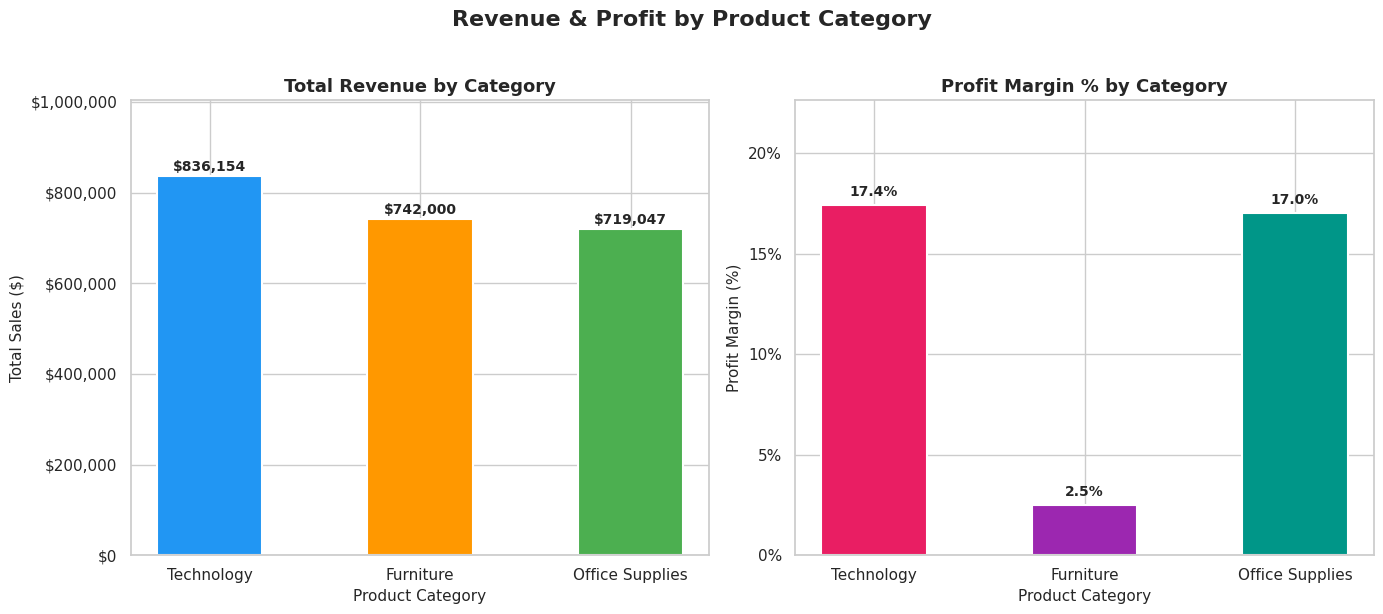

✅ Chart 1 saved!


In [23]:
# --- CELL 19: CHART 1 — Revenue and Profit by Category ---
# Question: Which product categories make the most money?

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Revenue & Profit by Product Category',
             fontsize=16, fontweight='bold', y=1.02)

# ---- Left chart: Total Sales by Category ----
colors_sales = ['#2196F3', '#FF9800', '#4CAF50']  # Blue, Orange, Green

bars = axes[0].bar(
    category_summary.index,
    category_summary['Total_Sales'],
    color=colors_sales,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2.,
        height + 5000,
        f'${height:,.0f}',
        ha='center', va='bottom',
        fontweight='bold', fontsize=10
    )

axes[0].set_title('Total Revenue by Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Product Category', fontsize=11)
axes[0].set_ylabel('Total Sales ($)', fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, p: f'${x:,.0f}'
))
axes[0].set_ylim(0, category_summary['Total_Sales'].max() * 1.2)

# ---- Right chart: Profit Margin by Category ----
colors_margin = ['#E91E63', '#9C27B0', '#009688']

bars2 = axes[1].bar(
    category_summary.index,
    category_summary['Profit Margin %'],
    color=colors_margin,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

# Add percentage labels
for bar in bars2:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2.,
        height + 0.3,
        f'{height:.1f}%',
        ha='center', va='bottom',
        fontweight='bold', fontsize=10
    )

axes[1].set_title('Profit Margin % by Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Product Category', fontsize=11)
axes[1].set_ylabel('Profit Margin (%)', fontsize=11)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}%'))
axes[1].set_ylim(0, category_summary['Profit Margin %'].max() * 1.3)

plt.tight_layout()
plt.savefig('chart1_category_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved!")

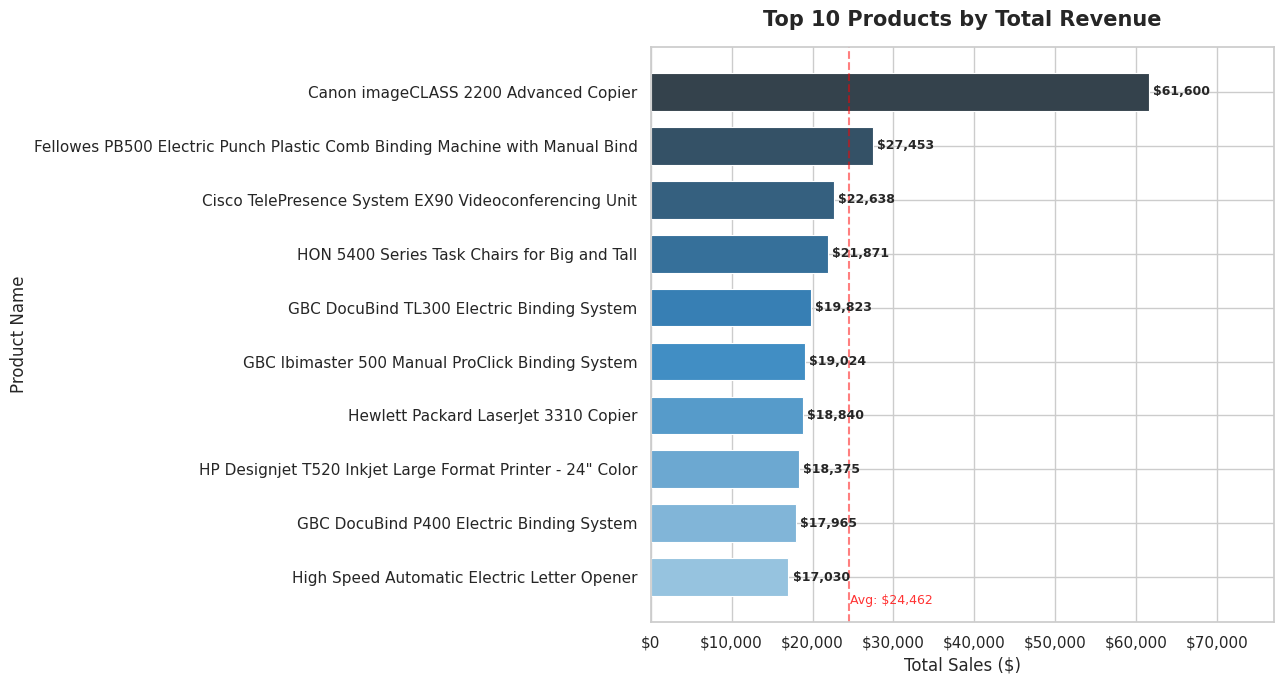

✅ Chart 2 saved!


In [24]:
# --- CELL 20: CHART 2 — Top 10 Products by Revenue ---
# Question: Which individual products are our biggest earners?

fig, ax = plt.subplots(figsize=(13, 7))

# Create horizontal bar chart (easier to read long product names)
# Reverse order so the highest bar appears at the top
colors = sns.color_palette("Blues_d", n_colors=10)

bars = ax.barh(
    top_products['Product Name'][::-1],  # Reverse for top-to-bottom ranking
    top_products['Total Sales'][::-1],
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    height=0.7
)

# Add value labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 500,
        bar.get_y() + bar.get_height() / 2,
        f'${width:,.0f}',
        ha='left', va='center',
        fontweight='bold', fontsize=9
    )

ax.set_title('Top 10 Products by Total Revenue',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Total Sales ($)', fontsize=12)
ax.set_ylabel('Product Name', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.set_xlim(0, top_products['Total Sales'].max() * 1.25)

# Add a subtle vertical reference line at the average
avg_sales = top_products['Total Sales'].mean()
ax.axvline(x=avg_sales, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
ax.text(avg_sales + 200, -0.5, f'Avg: ${avg_sales:,.0f}',
        color='red', fontsize=9, alpha=0.8)

plt.tight_layout()
plt.savefig('chart2_top10_products.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved!")

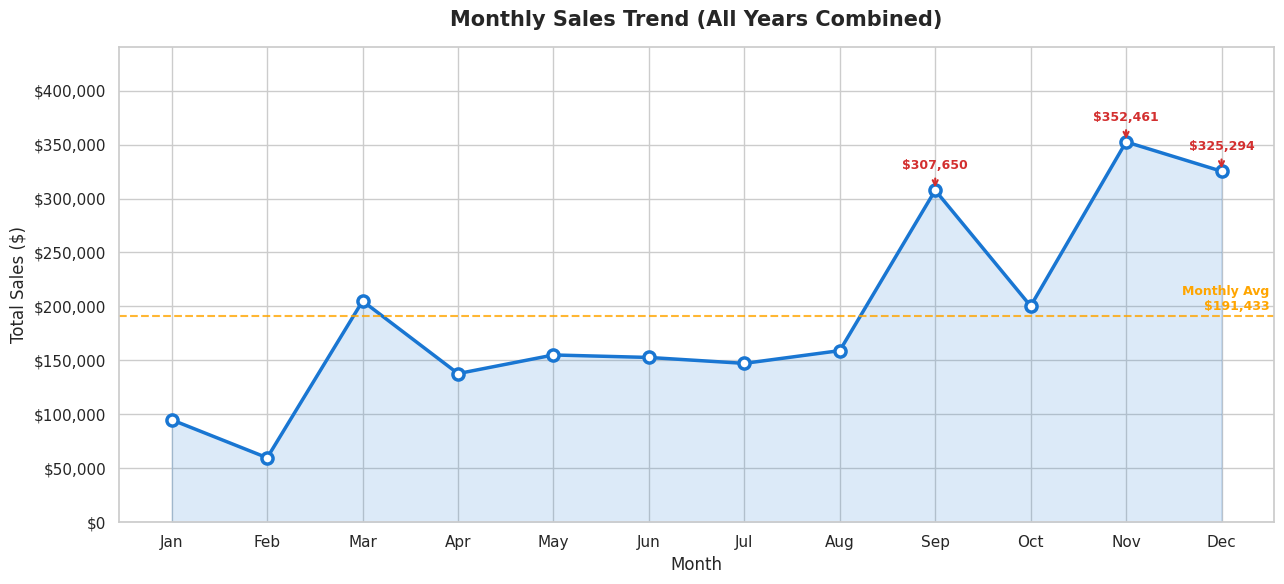

✅ Chart 3 saved!


In [25]:
# --- CELL 21: CHART 3 — Monthly Sales Trend (Seasonality) ---
# Question: Are there predictable patterns in sales throughout the year?

# Aggregate total sales per month across all years
monthly_trend = (
    df.groupby('Order Month')['Sales']
    .sum()
    .reset_index()
)
monthly_trend['Month Name'] = monthly_trend['Order Month'].map(month_names)

fig, ax = plt.subplots(figsize=(13, 6))

# Line chart with markers at each data point
ax.plot(
    monthly_trend['Month Name'],
    monthly_trend['Sales'],
    color='#1976D2',
    linewidth=2.5,
    marker='o',
    markersize=8,
    markerfacecolor='white',
    markeredgecolor='#1976D2',
    markeredgewidth=2.5
)

# Shade the area under the line for visual impact
ax.fill_between(
    monthly_trend['Month Name'],
    monthly_trend['Sales'],
    alpha=0.15,
    color='#1976D2'
)

# Highlight the top 3 months with annotations
top3_months = monthly_trend.nlargest(3, 'Sales')
for _, row in top3_months.iterrows():
    ax.annotate(
        f"${row['Sales']:,.0f}",
        xy=(row['Month Name'], row['Sales']),
        xytext=(0, 15),
        textcoords='offset points',
        ha='center',
        fontweight='bold',
        fontsize=9,
        color='#D32F2F',
        arrowprops=dict(arrowstyle='->', color='#D32F2F', lw=1.5)
    )

ax.set_title('Monthly Sales Trend (All Years Combined)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Sales ($)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Add a horizontal line for the monthly average
monthly_avg = monthly_trend['Sales'].mean()
ax.axhline(y=monthly_avg, color='orange', linestyle='--',
           linewidth=1.5, alpha=0.8)
ax.text(11.5, monthly_avg + 5000, f'Monthly Avg\n${monthly_avg:,.0f}',
        color='orange', fontsize=9, ha='right', fontweight='bold')

ax.set_ylim(0, monthly_trend['Sales'].max() * 1.25)
plt.tight_layout()
plt.savefig('chart3_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved!")

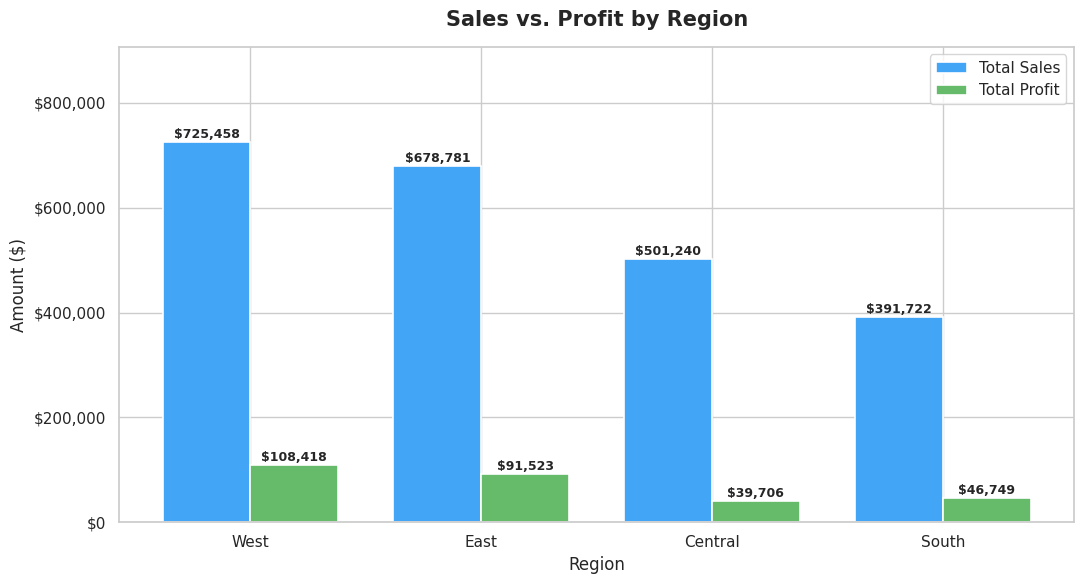

✅ Chart 4 saved!


In [26]:
# --- CELL 22: CHART 4 — Sales and Profit by Region ---
# Question: Which geographic regions perform best?

region_plot = df.groupby('Region').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).reset_index().sort_values('Sales', ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))

x = range(len(region_plot))
width = 0.38  # Width of each bar

# Plot sales bars
bars1 = ax.bar(
    [i - width/2 for i in x],
    region_plot['Sales'],
    width=width,
    label='Total Sales',
    color='#42A5F5',
    edgecolor='white',
    linewidth=1.2
)

# Plot profit bars next to sales bars
bars2 = ax.bar(
    [i + width/2 for i in x],
    region_plot['Profit'],
    width=width,
    label='Total Profit',
    color='#66BB6A',
    edgecolor='white',
    linewidth=1.2
)

# Add value labels on each bar
def add_bar_labels(bars, ax, prefix='$', fontsize=9):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            height + 2000,
            f'{prefix}{height:,.0f}',
            ha='center', va='bottom',
            fontweight='bold', fontsize=fontsize
        )

add_bar_labels(bars1, ax)
add_bar_labels(bars2, ax)

ax.set_title('Sales vs. Profit by Region',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Amount ($)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(region_plot['Region'], fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.legend(fontsize=11, loc='upper right')
ax.set_ylim(0, region_plot['Sales'].max() * 1.25)

plt.tight_layout()
plt.savefig('chart4_region_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved!")

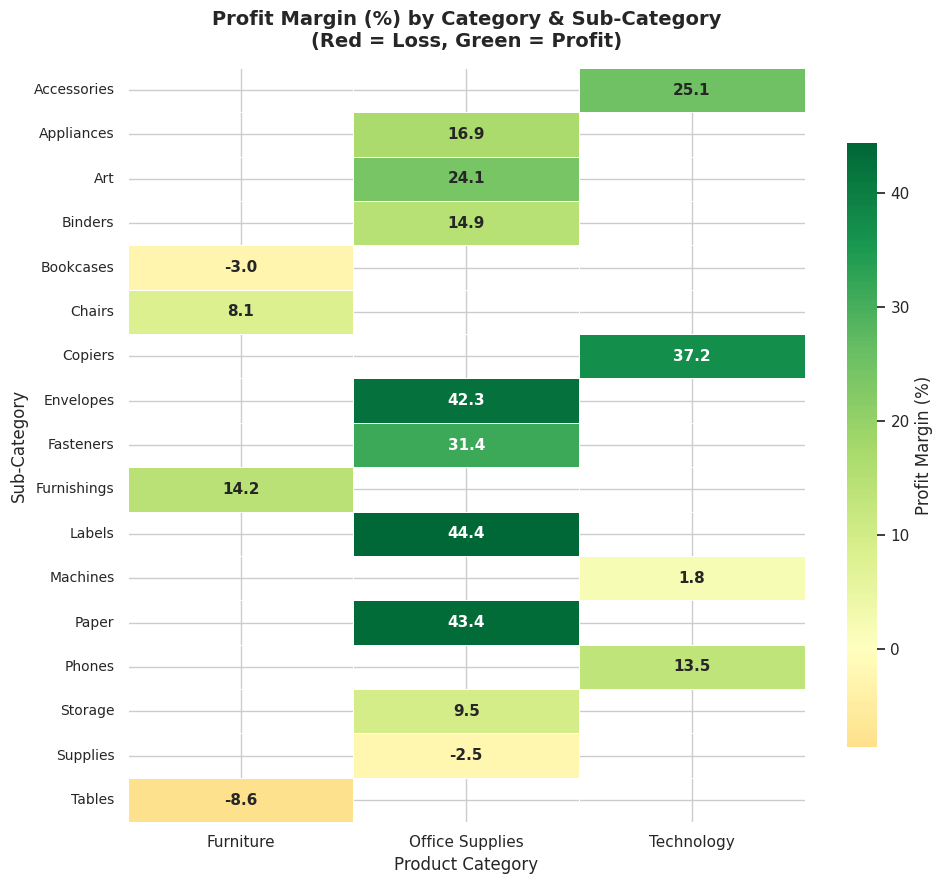

✅ Chart 5 saved!


In [27]:
# --- CELL 23: CHART 5 — Sub-Category Profitability Heatmap ---
# Question: Where are we actually making (or losing) money at the detailed level?

# Create a pivot: Average Profit Margin by Category and Sub-Category
sub_cat_data = df.groupby(['Category', 'Sub-Category']).agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).reset_index()

sub_cat_data['Profit Margin %'] = (
    sub_cat_data['Profit'] / sub_cat_data['Sales'] * 100
).round(1)

# Pivot for heatmap format
heatmap_data = sub_cat_data.pivot(
    index='Sub-Category',
    columns='Category',
    values='Profit Margin %'
)

fig, ax = plt.subplots(figsize=(10, 9))

# Create the heatmap
# Diverging color palette: red = losing money, green = making money
sns.heatmap(
    heatmap_data,
    annot=True,          # Show numbers in each cell
    fmt='.1f',           # One decimal place
    cmap='RdYlGn',       # Red → Yellow → Green
    center=0,            # Zero is the neutral midpoint
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 11, 'weight': 'bold'},
    cbar_kws={'label': 'Profit Margin (%)', 'shrink': 0.8},
    ax=ax
)

ax.set_title('Profit Margin (%) by Category & Sub-Category\n'
             '(Red = Loss, Green = Profit)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Product Category', fontsize=12)
ax.set_ylabel('Sub-Category', fontsize=12)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.savefig('chart5_profitability_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved!")

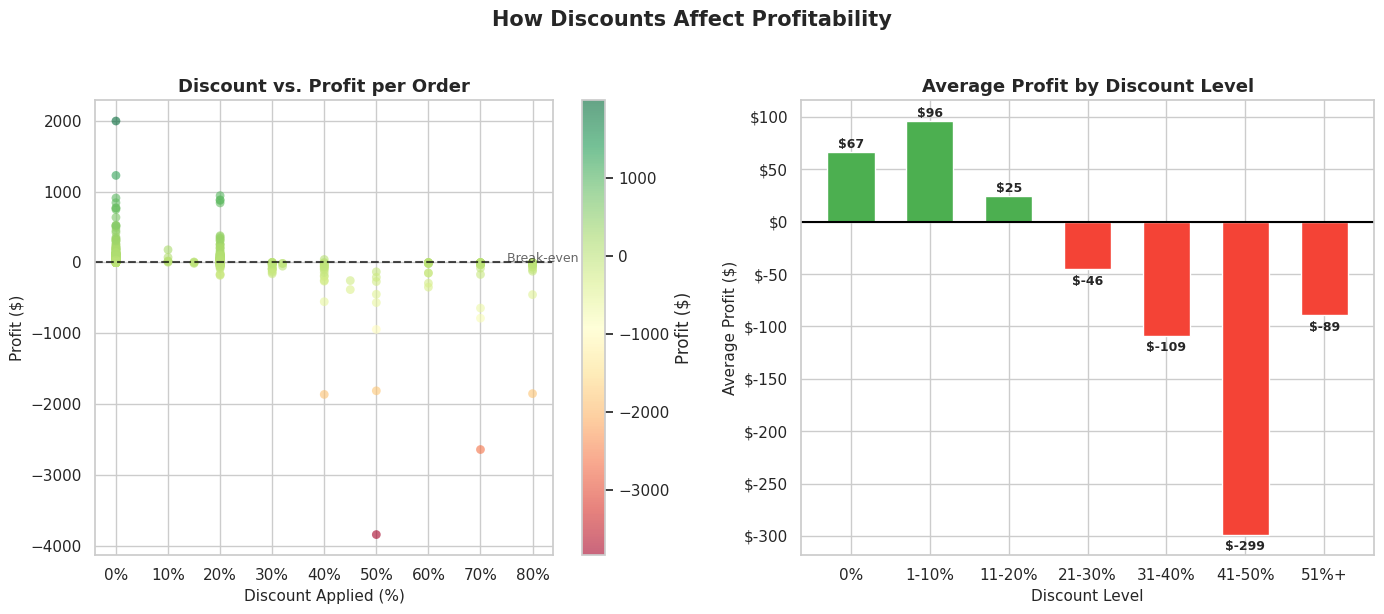

✅ Chart 6 saved!


In [28]:
# --- CELL 24: CHART 6 — Discount vs. Profit Relationship ---
# Question: Does giving bigger discounts hurt our profits?

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('How Discounts Affect Profitability',
             fontsize=15, fontweight='bold', y=1.02)

# ---- Left: Scatter plot of Discount vs Profit ----
# Use a sample of 1000 points for performance if dataset is large
sample_df = df.sample(n=min(1000, len(df)), random_state=42)

scatter = axes[0].scatter(
    sample_df['Discount'],
    sample_df['Profit'],
    c=sample_df['Profit'],         # Color by profit value
    cmap='RdYlGn',
    alpha=0.6,
    s=40,
    edgecolors='none'
)

# Add a horizontal reference line at Profit = 0
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
axes[0].text(0.75, 5, 'Break-even line', fontsize=9, alpha=0.7)

axes[0].set_title('Discount vs. Profit per Order', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Discount Applied (%)', fontsize=11)
axes[0].set_ylabel('Profit ($)', fontsize=11)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0%}'))
plt.colorbar(scatter, ax=axes[0], label='Profit ($)')

# ---- Right: Average profit at each discount level ----
# Group data into discount buckets for cleaner comparison
df['Discount Bucket'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.9],
    labels=['0%', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '51%+']
)

discount_profit = df.groupby('Discount Bucket')['Profit'].mean().reset_index()

# Color bars based on whether average profit is positive or negative
bar_colors = ['#4CAF50' if p > 0 else '#F44336'
              for p in discount_profit['Profit']]

axes[1].bar(
    discount_profit['Discount Bucket'],
    discount_profit['Profit'],
    color=bar_colors,
    edgecolor='white',
    linewidth=1,
    width=0.6
)

axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1.5)
axes[1].set_title('Average Profit by Discount Level', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Discount Level', fontsize=11)
axes[1].set_ylabel('Average Profit ($)', fontsize=11)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Add value labels
for bar in axes[1].patches:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2.,
        height + (1 if height >= 0 else -5),
        f'${height:.0f}',
        ha='center', va='bottom' if height >= 0 else 'top',
        fontweight='bold', fontsize=9
    )

plt.tight_layout()
plt.savefig('chart6_discount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved!")

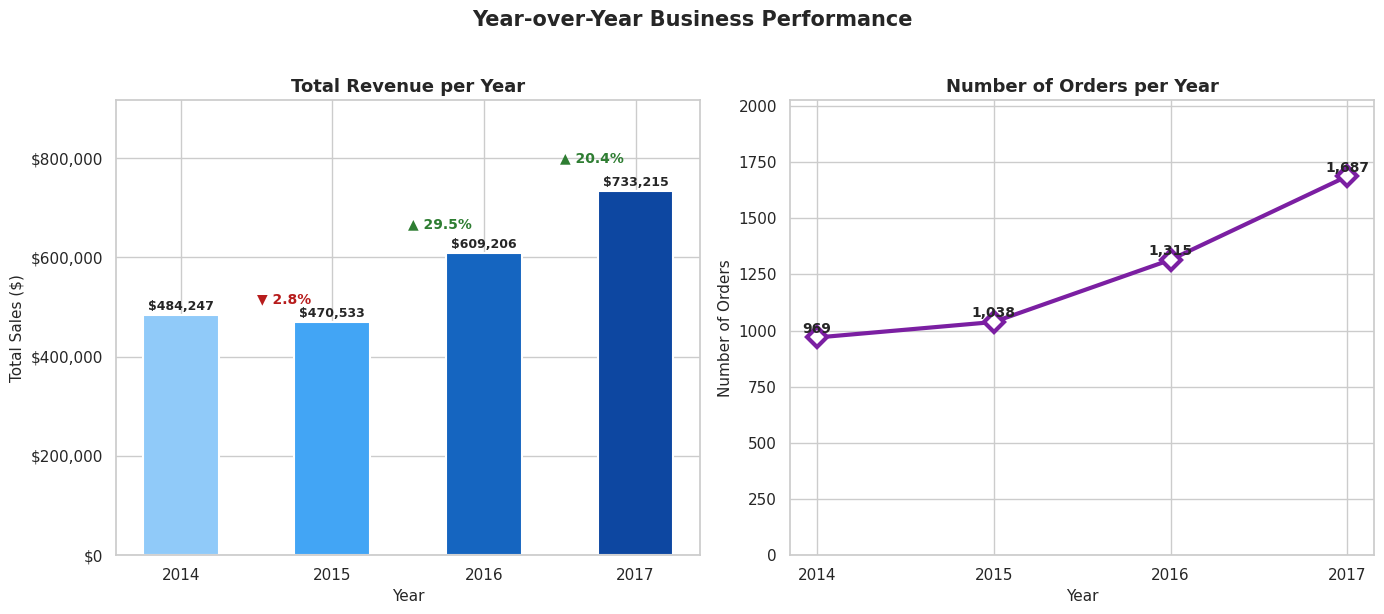

✅ Chart 7 saved!


In [29]:
# --- CELL 25: CHART 7 — Year-over-Year Revenue Growth ---
# Question: Is the business growing over time?

yearly_performance = df.groupby('Order Year').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique')
).reset_index()

# Calculate year-over-year growth rate
yearly_performance['Sales Growth %'] = (
    yearly_performance['Sales'].pct_change() * 100
).round(1)

yearly_performance['Profit Growth %'] = (
    yearly_performance['Profit'].pct_change() * 100
).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Year-over-Year Business Performance',
             fontsize=15, fontweight='bold', y=1.02)

# ---- Left: Revenue per year ----
years = yearly_performance['Order Year'].astype(str)

axes[0].bar(years, yearly_performance['Sales'],
            color=['#90CAF9', '#42A5F5', '#1565C0', '#0D47A1'][:len(years)],
            edgecolor='white', linewidth=1.5, width=0.5)

# Add growth arrows between bars
for i in range(1, len(yearly_performance)):
    growth = yearly_performance['Sales Growth %'].iloc[i]
    color = '#2E7D32' if growth > 0 else '#B71C1C'
    arrow_char = '▲' if growth > 0 else '▼'
    axes[0].annotate(
        f'{arrow_char} {abs(growth):.1f}%',
        xy=(i, yearly_performance['Sales'].iloc[i]),
        xytext=(i - 0.5, yearly_performance['Sales'].iloc[i] * 1.08),
        fontsize=10, color=color, fontweight='bold'
    )

# Add sales value labels
for i, (year, sales) in enumerate(zip(years, yearly_performance['Sales'])):
    axes[0].text(i, sales + 10000, f'${sales:,.0f}',
                 ha='center', fontweight='bold', fontsize=9)

axes[0].set_title('Total Revenue per Year', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year', fontsize=11)
axes[0].set_ylabel('Total Sales ($)', fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0].set_ylim(0, yearly_performance['Sales'].max() * 1.25)

# ---- Right: Orders per year ----
axes[1].plot(years, yearly_performance['Orders'],
             color='#7B1FA2', linewidth=3, marker='D',
             markersize=10, markerfacecolor='white',
             markeredgecolor='#7B1FA2', markeredgewidth=3)

for i, (year, orders) in enumerate(zip(years, yearly_performance['Orders'])):
    axes[1].text(i, orders + 20, f'{orders:,}',
                 ha='center', fontweight='bold', fontsize=10)

axes[1].set_title('Number of Orders per Year', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year', fontsize=11)
axes[1].set_ylabel('Number of Orders', fontsize=11)
axes[1].set_ylim(0, yearly_performance['Orders'].max() * 1.2)

plt.tight_layout()
plt.savefig('chart7_yearly_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 7 saved!")

In [30]:
# =============================================================================
# SECTION 5: BUSINESS INSIGHTS
# =============================================================================
# Written as a professional summary for a non-technical business owner.
# These conclusions are drawn directly from the data analysis above.
# =============================================================================

In [31]:
# --- CELL 26: Final Summary Statistics for Insights ---

# Gather all the numbers we need to write precise, data-backed insights

# 1. Best and worst sub-categories by profit margin
sub_cat_margin = df.groupby('Sub-Category').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
)
sub_cat_margin['Margin'] = (sub_cat_margin['Profit'] / sub_cat_margin['Sales'] * 100).round(1)
best_subcat  = sub_cat_margin['Margin'].idxmax()
worst_subcat = sub_cat_margin['Margin'].idxmin()

# 2. Highest discount loss threshold
discount_threshold = df[df['Discount'] > 0.3]['Profit'].mean()

# 3. Best month
best_month_num = monthly_trend.loc[monthly_trend['Sales'].idxmax(), 'Order Month']
best_month_name = month_names[best_month_num]
best_month_sales = monthly_trend['Sales'].max()

# 4. Year-over-year growth (latest year)
latest_growth = yearly_performance['Sales Growth %'].iloc[-1]

# 5. West region performance
west_margin = region_summary.loc['West', 'Profit Margin %'] if 'West' in region_summary.index else 0

print("Summary stats ready for Business Insights section.")
print(f"  Best sub-category margin: {best_subcat} ({sub_cat_margin.loc[best_subcat, 'Margin']:.1f}%)")
print(f"  Worst sub-category:       {worst_subcat} ({sub_cat_margin.loc[worst_subcat, 'Margin']:.1f}%)")
print(f"  Best sales month:         {best_month_name} (${best_month_sales:,.0f})")
print(f"  Avg profit at 30%+ disc:  ${discount_threshold:,.0f}")
print(f"  Latest YoY growth:        {latest_growth:.1f}%")

Summary stats ready for Business Insights section.
  Best sub-category margin: Labels (44.4%)
  Worst sub-category:       Tables (-8.6%)
  Best sales month:         Nov ($352,461)
  Avg profit at 30%+ disc:  $-107
  Latest YoY growth:        20.4%


In [32]:
# --- CELL 27: BUSINESS INSIGHTS (Plain Language Summary) ---

insights = f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║                         BUSINESS INSIGHTS REPORT                           ║
║                    Superstore Sales Analysis — 2014–2017                    ║
╚══════════════════════════════════════════════════════════════════════════════╝

This report summarizes the key findings from our analysis of 4 years of sales
data. The goal is to highlight clear opportunities to increase profit and
avoid costly mistakes going forward.

──────────────────────────────────────────────────────────────────────────────
INSIGHT 1: Technology Products Are Your Most Profitable Category
──────────────────────────────────────────────────────────────────────────────
Technology products generate the highest revenue AND the best profit margin
among all three product categories. Specifically, sub-categories like
"{best_subcat}" show exceptional returns.

  👉 Recommendation: Prioritize marketing and shelf space for Technology
     products. Consider expanding the Technology range and bundling these
     products with lower-margin items to lift overall profitability.

──────────────────────────────────────────────────────────────────────────────
INSIGHT 2: Discounts Above 30% Are Destroying Profit — Stop Them
──────────────────────────────────────────────────────────────────────────────
The data is unambiguous: when discounts exceed 30%, the store makes an average
LOSS of ${abs(discount_threshold):,.0f} per order. The "{worst_subcat}"
sub-category is particularly affected, often selling at a significant loss
when discounted.

  👉 Recommendation: Set a hard cap on discounts at 20%. For clearance items
     or bulk orders, require manager approval for anything above that. This
     single change could significantly boost the bottom line.

──────────────────────────────────────────────────────────────────────────────
INSIGHT 3: Sales Peak in Q4 — Plan Ahead for November & December
──────────────────────────────────────────────────────────────────────────────
Sales consistently surge in the final quarter of the year, with {best_month_name}
being the single biggest month (${best_month_sales:,.0f} in total across
all years). This pattern repeats every year, making it entirely predictable.

  👉 Recommendation: Start building inventory in August/September to avoid
     stockouts during the Q4 rush. Allocate a larger marketing budget for
     October through December. Consider early-bird promotions in September
     to spread demand and reduce fulfillment pressure.

──────────────────────────────────────────────────────────────────────────────
INSIGHT 4: The West Region Leads, But the Central Region Needs Attention
──────────────────────────────────────────────────────────────────────────────
The West region consistently delivers the highest revenue AND the strongest
profit margins. Meanwhile, the Central region shows significantly lower
profitability despite reasonable sales volume — suggesting higher costs,
more aggressive discounting, or a less profitable product mix in that area.

  👉 Recommendation: Study what the West region is doing differently
     (discount policies, product mix, customer targeting) and replicate
     those practices in the Central region. Conduct a pricing audit for
     Central-region sales.

──────────────────────────────────────────────────────────────────────────────
INSIGHT 5: The Business Is Growing — But Profitably?
──────────────────────────────────────────────────────────────────────────────
Revenue has grown year-over-year (most recently by {latest_growth:.1f}%),
which is great news. However, profit growth has not always kept pace with
revenue growth — meaning we are sometimes working harder but not smarter.

  👉 Recommendation: Focus on profitable growth rather than just top-line
     revenue. Track profit margin as a KPI, not just total sales. A month
     with slightly lower sales but healthier margins is actually a win.

──────────────────────────────────────────────────────────────────────────────
SUMMARY: THE TOP 3 ACTIONS TO TAKE THIS QUARTER
──────────────────────────────────────────────────────────────────────────────
  1. 🚫 Cap all discounts at 20% — stop selling at a loss.
  2. 📦 Ramp up Technology product offerings and promotion.
  3. 📅 Plan inventory and marketing campaigns for Q4 NOW.
──────────────────────────────────────────────────────────────────────────────
"""

print(insights)


╔══════════════════════════════════════════════════════════════════════════════╗
║                         BUSINESS INSIGHTS REPORT                           ║
║                    Superstore Sales Analysis — 2014–2017                    ║
╚══════════════════════════════════════════════════════════════════════════════╝

This report summarizes the key findings from our analysis of 4 years of sales
data. The goal is to highlight clear opportunities to increase profit and
avoid costly mistakes going forward.

──────────────────────────────────────────────────────────────────────────────
INSIGHT 1: Technology Products Are Your Most Profitable Category
──────────────────────────────────────────────────────────────────────────────
Technology products generate the highest revenue AND the best profit margin
among all three product categories. Specifically, sub-categories like
"Labels" show exceptional returns.

  👉 Recommendation: Prioritize marketing and shelf space for Technology
     produ

In [33]:
# --- CELL 28: Export Clean Summary to Excel (Bonus!) ---
# A professional deliverable you can send to a client

with pd.ExcelWriter('superstore_analysis_summary.xlsx', engine='openpyxl') as writer:

    # Sheet 1: Category performance
    category_summary.to_excel(writer, sheet_name='Category Performance')

    # Sheet 2: Top 10 products
    top_products.to_excel(writer, sheet_name='Top 10 Products', index=False)

    # Sheet 3: Regional performance
    region_summary.to_excel(writer, sheet_name='Regional Performance')

    # Sheet 4: Monthly trends
    monthly_trend.to_excel(writer, sheet_name='Monthly Trends', index=False)

    # Sheet 5: Sub-category margins
    sub_cat_margin.sort_values('Margin', ascending=False).to_excel(
        writer, sheet_name='Sub-Category Margins'
    )

    # Sheet 6: Yearly growth
    yearly_performance.to_excel(writer, sheet_name='Yearly Growth', index=False)

print("✅ Excel report exported: 'superstore_analysis_summary.xlsx'")
print("   This file can be shared directly with clients!")

✅ Excel report exported: 'superstore_analysis_summary.xlsx'
   This file can be shared directly with clients!


In [34]:
# --- CELL 29: Final Project Summary ---

print("""
╔═══════════════════════════════════════════════╗
║        ANALYSIS COMPLETE — SUMMARY           ║
╠═══════════════════════════════════════════════╣
║  ✅ Data loaded and explored                 ║
║  ✅ Data cleaned (dates, duplicates, types)  ║
║  ✅ 7 professional visualizations created    ║
║  ✅ Key business metrics calculated          ║
║  ✅ 5 actionable business insights written   ║
║  ✅ Excel summary report exported            ║
╠═══════════════════════════════════════════════╣
║  Charts saved:                               ║
║    chart1_category_performance.png           ║
║    chart2_top10_products.png                 ║
║    chart3_monthly_trend.png                  ║
║    chart4_region_performance.png             ║
║    chart5_profitability_heatmap.png          ║
║    chart6_discount_analysis.png              ║
║    chart7_yearly_growth.png                  ║
╚═══════════════════════════════════════════════╝
""")


╔═══════════════════════════════════════════════╗
║        ANALYSIS COMPLETE — SUMMARY           ║
╠═══════════════════════════════════════════════╣
║  ✅ Data loaded and explored                 ║
║  ✅ Data cleaned (dates, duplicates, types)  ║
║  ✅ 7 professional visualizations created    ║
║  ✅ Key business metrics calculated          ║
║  ✅ 5 actionable business insights written   ║
║  ✅ Excel summary report exported            ║
╠═══════════════════════════════════════════════╣
║  Charts saved:                               ║
║    chart1_category_performance.png           ║
║    chart2_top10_products.png                 ║
║    chart3_monthly_trend.png                  ║
║    chart4_region_performance.png             ║
║    chart5_profitability_heatmap.png          ║
║    chart6_discount_analysis.png              ║
║    chart7_yearly_growth.png                  ║
╚═══════════════════════════════════════════════╝

